#Proyecto Final Módulo
##Machine Learning
**Evaluación Crediticia para Alke Wallet**

#Preparación (instalaciones y librerías)

En Colab normalmente ya están pandas, numpy y scikit-learn. Si se ven errores de librerías, descomentar las líneas pip.

In [1]:
# !pip install scikit-learn joblib fastapi uvicorn pydantic

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from numpy.random import default_rng
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)
import joblib

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Compatibilidad OneHotEncoder (dense):
try:
    OHE = OneHotEncoder(handle_unknown="ignore", sparse_output=False)  # sklearn >= 1.2
except TypeError:
    OHE = OneHotEncoder(handle_unknown="ignore", sparse=False)         # sklearn < 1.2

#1) Cargar o generar dataset sintético

Contexto: evaluación crediticia (fintech).
Objetivo (y): apto (0/1).
Features (X): edad, ingresos, deuda, morosidad, historial, empleo, región, etc.

In [2]:
CSV_PATH = "/content/sample_data/credit_dataset_clasificacion.csv"

def generar_dataset_sintetico(n=500, seed=42):
    rng = default_rng(seed)
    historial_choices = ["bueno", "regular", "malo"]
    empleo_choices = ["dependiente", "independiente", "estudiante", "desempleado"]
    region_choices = ["norte", "centro", "sur", "metropolitana"]

    edad = rng.integers(18, 70, size=n)
    ingresos_mensuales = np.round(rng.lognormal(mean=7.8, sigma=0.5, size=n))
    antiguedad_laboral = rng.integers(0, 30, size=n)
    deuda_total = np.round(rng.lognormal(mean=9.0, sigma=0.7, size=n))
    porcentaje_uso_credito = np.clip(rng.normal(loc=45, scale=20, size=n), 0, 100)
    morosidad_12m = rng.poisson(0.6, size=n)
    historial_crediticio = rng.choice(historial_choices, size=n, p=[0.55, 0.25, 0.20])
    tipo_empleo = rng.choice(empleo_choices, size=n, p=[0.55, 0.25, 0.1, 0.10])
    region = rng.choice(region_choices, size=n, p=[0.15, 0.45, 0.15, 0.25])
    tiene_tarjeta = rng.integers(0, 2, size=n)
    solicitante_nuevo = rng.integers(0, 2, size=n)

    # "score" latente y umbral para definir apto
    score = (
        (ingresos_mensuales / np.percentile(ingresos_mensuales, 75)) * 0.9
        - (deuda_total / np.percentile(deuda_total, 75)) * 0.7
        - (porcentaje_uso_credito / 100) * 0.8
        - morosidad_12m * 0.9
        + (antiguedad_laboral / 30) * 0.8
        + (tiene_tarjeta * 0.2)
        - (solicitante_nuevo * 0.3)
    )
    historial_map = {"bueno": 0.8, "regular": 0.2, "malo": -0.6}
    score += pd.Series(historial_crediticio).map(historial_map).values
    score += rng.normal(0, 0.5, size=n)
    threshold = np.median(score)
    apto = (score > threshold).astype(int)

    df = pd.DataFrame({
        "edad": edad,
        "ingresos_mensuales": ingresos_mensuales.astype(int),
        "antiguedad_laboral_anios": antiguedad_laboral,
        "deuda_total": deuda_total.astype(int),
        "porcentaje_uso_credito": np.round(porcentaje_uso_credito, 1),
        "morosidad_12m": morosidad_12m,
        "historial_crediticio": historial_crediticio,
        "tipo_empleo": tipo_empleo,
        "region": region,
        "tiene_tarjeta": tiene_tarjeta,
        "solicitante_nuevo": solicitante_nuevo,
        "apto": apto
    })
    return df

if os.path.exists(CSV_PATH):
    df = pd.read_csv(CSV_PATH)
else:
    df = generar_dataset_sintetico(n=500, seed=RANDOM_STATE)
    df.to_csv(CSV_PATH, index=False)

df.head()

,edad,ingresos_mensuales,antiguedad_laboral_anios,deuda_total,porcentaje_uso_credito,morosidad_12m,historial_crediticio,tipo_empleo,region,tiene_tarjeta,solicitante_nuevo,apto
0,22,2328,2,6556,51.6,0,regular,independiente,centro,1,1,0
1,58,1013,17,5779,48.6,0,bueno,dependiente,centro,1,0,1
2,52,1172,6,14904,32.7,2,bueno,dependiente,centro,0,0,0
3,40,7077,17,22822,44.5,1,bueno,dependiente,centro,1,0,0
4,40,1282,20,28454,32.5,0,malo,dependiente,centro,1,0,0


#2) EDA (Análisis Exploratorio)

Objetivos: entender estructura, nulos, distribuciones, balance de clases y correlaciones numéricas.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   edad                      500 non-null    int64  
 1   ingresos_mensuales        500 non-null    int64  
 2   antiguedad_laboral_anios  500 non-null    int64  
 3   deuda_total               500 non-null    int64  
 4   porcentaje_uso_credito    500 non-null    float64
 5   morosidad_12m             500 non-null    int64  
 6   historial_crediticio      500 non-null    object 
 7   tipo_empleo               500 non-null    object 
 8   region                    500 non-null    object 
 9   tiene_tarjeta             500 non-null    int64  
 10  solicitante_nuevo         500 non-null    int64  
 11  apto                      500 non-null    int64  
dtypes: float64(1), int64(8), object(3)
memory usage: 47.0+ KB


In [4]:
df.describe(include="all")

,edad,ingresos_mensuales,antiguedad_laboral_anios,deuda_total,porcentaje_uso_credito,morosidad_12m,historial_crediticio,tipo_empleo,region,tiene_tarjeta,solicitante_nuevo,apto
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500,500,500,500.000000,500.000000,500.000000
unique,NaN,NaN,NaN,NaN,NaN,NaN,3,4,4,NaN,NaN,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,bueno,dependiente,centro,NaN,NaN,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,281,261,235,NaN,NaN,NaN
mean,43.456000,2714.216000,14.290000,10533.036000,41.643200,0.630000,NaN,NaN,NaN,0.526000,0.456000,0.500000
std,14.858318,1443.629432,8.727786,8088.106755,19.681497,0.801489,NaN,NaN,NaN,0.499824,0.498559,0.500501
min,18.000000,554.000000,0.000000,1024.000000,0.000000,0.000000,NaN,NaN,NaN,0.000000,0.000000,0.000000
25%,31.000000,1680.750000,7.000000,5204.500000,28.850000,0.000000,NaN,NaN,NaN,0.000000,0.000000,0.000000
50%,43.000000,2421.500000,14.000000,8246.000000,41.950000,0.000000,NaN,NaN,NaN,1.000000,0.000000,0.500000
75%,56.250000,3311.750000,22.000000,13145.750000,55.100000,1.000000,NaN,NaN,NaN,1.000000,1.000000,1.000000


In [5]:
# Nulos por columna
df.isna().sum()

,0
edad,0
ingresos_mensuales,0
antiguedad_laboral_anios,0
deuda_total,0
porcentaje_uso_credito,0
morosidad_12m,0
historial_crediticio,0
tipo_empleo,0
region,0
tiene_tarjeta,0


In [6]:
# Balance de clases
df['apto'].value_counts(normalize=True)

,proportion
apto,
0,0.5
1,0.5


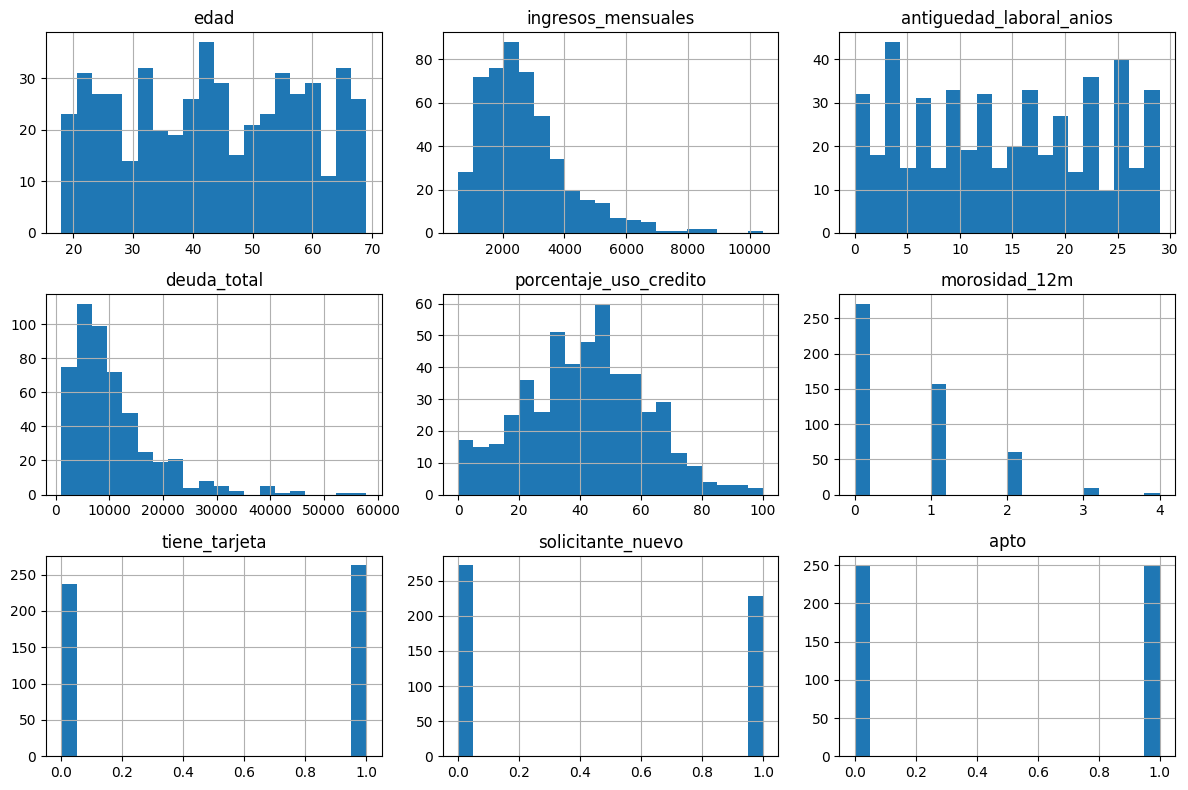

In [7]:
# Histograma de numéricas
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
_ = df[num_cols].hist(bins=20, figsize=(12, 8))
plt.tight_layout(); plt.show()

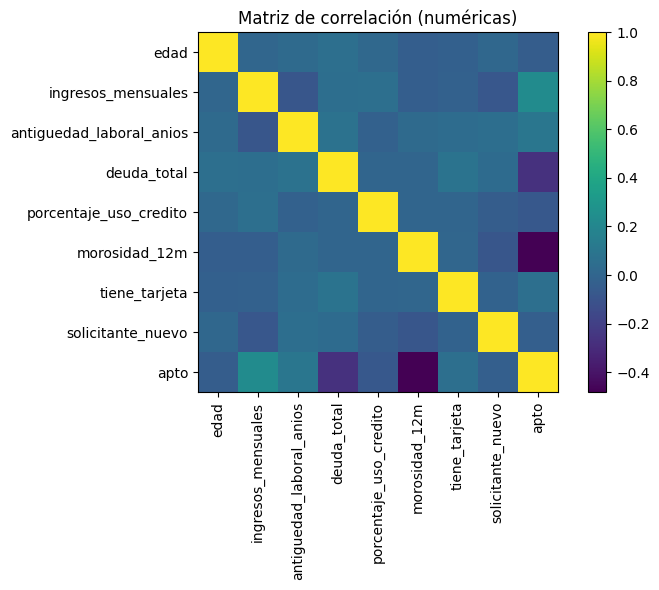

In [8]:
# Correlación entre variables numéricas
corr = df[num_cols].corr()
plt.figure(figsize=(8,6))
plt.imshow(corr, interpolation='nearest')
plt.title("Matriz de correlación (numéricas)")
plt.colorbar()
plt.xticks(range(len(num_cols)), num_cols, rotation=90)
plt.yticks(range(len(num_cols)), num_cols)
plt.tight_layout(); plt.show()

#3) Preprocesamiento y split

Target: apto

Train/Test estratificado

Pipelines:

Numéricas: SimpleImputer(median) + StandardScaler

Categóricas: SimpleImputer(most_frequent) + OneHotEncoder

In [9]:
target = "apto"
X = df.drop(columns=[target])
y = df[target]

cat_cols = X.select_dtypes(include=["object"]).columns.tolist()
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OHE),
])

preprocess = ColumnTransformer(transformers=[
    ("num", numeric_pipe, num_cols),
    ("cat", categorical_pipe, cat_cols),
])

#4) Validación cruzada (k-fold estratificado) y comparación de modelos

Evaluamos Logistic Regression, KNN y Random Forest con ROC-AUC, Accuracy, Precision, Recall y F1.

In [10]:
def cv_metrics(model, X, y, cv_splits=5):
    skf = StratifiedKFold(n_splits=cv_splits, shuffle=True, random_state=RANDOM_STATE)
    pipe = Pipeline(steps=[("prep", preprocess), ("model", model)])
    # Probabilidades para ROC-AUC
    y_proba = cross_val_predict(pipe, X, y, cv=skf, method="predict_proba")[:, 1]
    y_pred = (y_proba >= 0.5).astype(int)
    return {
        "accuracy": accuracy_score(y, y_pred),
        "precision": precision_score(y, y_pred),
        "recall": recall_score(y, y_pred),
        "f1": f1_score(y, y_pred),
        "roc_auc": roc_auc_score(y, y_proba),
    }

models = {
    "LogisticRegression": LogisticRegression(max_iter=300),
    "KNN": KNeighborsClassifier(n_neighbors=7),
    "RandomForest": RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE),
}

results = {name: cv_metrics(m, X_train, y_train, cv_splits=5) for name, m in models.items()}
pd.DataFrame(results).T.sort_values("roc_auc", ascending=False)

,accuracy,precision,recall,f1,roc_auc
LogisticRegression,0.8450,0.838235,0.855,0.846535,0.933725
RandomForest,0.8375,0.842640,0.830,0.836272,0.914600
KNN,0.7375,0.687747,0.870,0.768212,0.806025


#5) Selección del mejor modelo (por ROC-AUC en CV)

In [11]:
results_df = pd.DataFrame(results).T.sort_values("roc_auc", ascending=False)
best_name = results_df.index[0]
best_name, results_df

('LogisticRegression',
                     accuracy  precision  recall        f1   roc_auc
 LogisticRegression    0.8450   0.838235   0.855  0.846535  0.933725
 RandomForest          0.8375   0.842640   0.830  0.836272  0.914600
 KNN                   0.7375   0.687747   0.870  0.768212  0.806025)

#6) Entrenar el mejor modelo y evaluar en Test

Entrenamos Pipeline(preprocess + best_model)

Métricas en Test

Matriz de confusión y curva ROC

In [12]:
best_model = models[best_name]
final_pipe = Pipeline(steps=[("prep", preprocess), ("model", best_model)])
final_pipe.fit(X_train, y_train)

y_proba_test = final_pipe.predict_proba(X_test)[:, 1]
y_pred_test = (y_proba_test >= 0.5).astype(int)

test_metrics = {
    "accuracy": accuracy_score(y_test, y_pred_test),
    "precision": precision_score(y_test, y_pred_test),
    "recall": recall_score(y_test, y_pred_test),
    "f1": f1_score(y_test, y_pred_test),
    "roc_auc": roc_auc_score(y_test, y_proba_test),
}
test_metrics

{'accuracy': 0.93,
 'precision': 0.9387755102040817,
 'recall': 0.92,
 'f1': 0.9292929292929293,
 'roc_auc': np.float64(0.9751999999999998)}

#7) (Opcional) Tuning rápido con GridSearchCV

Solo si quieres exprimir un poco más el mejor modelo

In [13]:
param_grid = {}
if best_name == "LogisticRegression":
    param_grid = {"model__C": [0.1, 1, 3, 10], "model__penalty": ["l2"]}
elif best_name == "KNN":
    param_grid = {"model__n_neighbors": [3,5,7,9,11]}
elif best_name == "RandomForest":
    param_grid = {"model__n_estimators": [200,300,500], "model__max_depth": [None, 6, 10]}

grid = GridSearchCV(
    Pipeline([("prep", preprocess), ("model", models[best_name])]),
    param_grid=param_grid,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1
)
grid.fit(X_train, y_train)
grid.best_params_, grid.best_score_

({'model__C': 1, 'model__penalty': 'l2'}, np.float64(0.929))

In [14]:
best_pipe = grid.best_estimator_
y_proba_test_gs = best_pipe.predict_proba(X_test)[:, 1]
y_pred_test_gs = (y_proba_test_gs >= 0.5).astype(int)
{
    "accuracy": accuracy_score(y_test, y_pred_test_gs),
    "precision": precision_score(y_test, y_pred_test_gs),
    "recall": recall_score(y_test, y_pred_test_gs),
    "f1": f1_score(y_test, y_pred_test_gs),
    "roc_auc": roc_auc_score(y_test, y_proba_test_gs),
}

{'accuracy': 0.93,
 'precision': 0.9387755102040817,
 'recall': 0.92,
 'f1': 0.9292929292929293,
 'roc_auc': np.float64(0.9751999999999998)}

Si mejora, usar best_pipe; si no, mantener final_pipe

In [15]:
# Elegimos qué pipeline conservar como final:
pipeline_final = best_pipe if 'best_pipe' in globals() else final_pipe

#8) Guardar el modelo (pipeline) con joblib

In [16]:
MODEL_PATH = "modelo_credito_pipeline.joblib"
joblib.dump(pipeline_final, MODEL_PATH)
MODEL_PATH

'modelo_credito_pipeline.joblib'

9) Inferencia con nuevos datos

In [17]:
nuevo = pd.DataFrame([{
    "edad": 35,
    "ingresos_mensuales": 1500000,
    "antiguedad_laboral_anios": 5,
    "deuda_total": 800000,
    "porcentaje_uso_credito": 35.0,
    "morosidad_12m": 0,
    "historial_crediticio": "bueno",
    "tipo_empleo": "dependiente",
    "region": "metropolitana",
    "tiene_tarjeta": 1,
    "solicitante_nuevo": 0
}])

proba = pipeline_final.predict_proba(nuevo)[0,1]
pred = int(proba >= 0.5)
{"prediccion_apto": pred, "probabilidad_apto": float(proba)}

{'prediccion_apto': 1, 'probabilidad_apto': 1.0}

#9) Inferencia con nuevos datos

In [18]:
nuevo = pd.DataFrame([{
    "edad": 35,
    "ingresos_mensuales": 1500000,
    "antiguedad_laboral_anios": 5,
    "deuda_total": 800000,
    "porcentaje_uso_credito": 35.0,
    "morosidad_12m": 0,
    "historial_crediticio": "bueno",
    "tipo_empleo": "dependiente",
    "region": "metropolitana",
    "tiene_tarjeta": 1,
    "solicitante_nuevo": 0
}])

proba = pipeline_final.predict_proba(nuevo)[0,1]
pred = int(proba >= 0.5)
{"prediccion_apto": pred, "probabilidad_apto": float(proba)}

{'prediccion_apto': 1, 'probabilidad_apto': 1.0}

#10) API con FastAPI (snippet listo)

Crea un archivo app.py con:

In [19]:
!pip install fastapi uvicorn nest-asyncio pyngrok pydantic joblib scikit-learn




In [20]:
%%writefile app.py
from fastapi import FastAPI
from pydantic import BaseModel
import joblib
import pandas as pd

# Cargar modelo previamente entrenado
MODEL_PATH = "modelo_credito_pipeline.joblib"
model = joblib.load(MODEL_PATH)

# Inicializar API
app = FastAPI(title="API Evaluación Crediticia", version="1.0")

# Definir esquema de entrada con Pydantic
class Solicitud(BaseModel):
    edad: int
    ingresos_mensuales: float
    antiguedad_laboral_anios: int
    deuda_total: float
    porcentaje_uso_credito: float
    morosidad_12m: int
    historial_crediticio: str
    tipo_empleo: str
    region: str
    tiene_tarjeta: int
    solicitante_nuevo: int

# Ruta para predicción
@app.post("/predict")
def predict(req: Solicitud):
    entrada = pd.DataFrame([req.dict()])
    prob = model.predict_proba(entrada)[0, 1]
    pred = int(prob >= 0.5)
    return {
        "prediccion_apto": pred,
        "probabilidad_apto": round(float(prob), 4)
    }


Overwriting app.py


In [21]:
from pyngrok import ngrok

ngrok.set_auth_token("xxxxxxxxxxxxxxxxxx")



In [29]:
# Detener el servidor lanzado con subprocess
#process.terminate()
#print("Servidor FastAPI detenido.")


Servidor FastAPI detenido.


In [28]:
import subprocess

# Lanza el servidor FastAPI en segundo plano
process = subprocess.Popen(["uvicorn", "app:app", "--host", "0.0.0.0", "--port", "8000"])
print("Servidor FastAPI lanzado en segundo plano.")


Servidor FastAPI lanzado en segundo plano.


In [ ]:
from pyngrok import ngrok

public_url = ngrok.connect(8000)
print(f"Tu API está disponible en: {public_url}")


In [23]:
from pyngrok import ngrok

# En caso de error, asegurar que no haya túneles abiertos
ngrok.kill()

# Ahora conectar el puerto 8000 (donde está FastAPI corriendo)
public_url = ngrok.connect(8000)

print(f"La API ahora está disponible públicamente en:\n{public_url}")


La API ahora está disponible públicamente en:
NgrokTunnel: "https://5584a442bb58.ngrok-free.app" -> "http://localhost:8000"


In [26]:
!curl -X POST https://xxxxxxxx.ngrok-free.app \
-H "Content-Type: application/json" \
-d "{\"edad\": 35, \"ingresos_mensuales\": 1500000, \"antiguedad_laboral_anios\": 5, \"deuda_total\": 800000, \"porcentaje_uso_credito\": 35.0, \"morosidad_12m\": 0, \"historial_crediticio\": \"bueno\", \"tipo_empleo\": \"dependiente\", \"region\": \"metropolitana\", \"tiene_tarjeta\": 1, \"solicitante_nuevo\": 0}"

#este paso se ejecuto en la interfaz interactiva de tu API desplegada llamada Swagger UI, que es parte de FastAPI.
{
  "edad": 35,
  "ingresos_mensuales": 1500000,
  "antiguedad_laboral_anios": 5,
  "deuda_total": 800000,
  "porcentaje_uso_credito": 35.0,
  "morosidad_12m": 0,
  "historial_crediticio": "bueno",
  "tipo_empleo": "dependiente",
  "region": "metropolitana",
  "tiene_tarjeta": 1,
  "solicitante_nuevo": 0
}



<!DOCTYPE html>
<html class="h-full" lang="en-US" dir="ltr">
  <head>
    <link rel="preload" href="https://cdn.ngrok.com/static/fonts/euclid-square/EuclidSquare-Regular-WebS.woff" as="font" type="font/woff" crossorigin="anonymous" />
    <link rel="preload" href="https://cdn.ngrok.com/static/fonts/euclid-square/EuclidSquare-RegularItalic-WebS.woff" as="font" type="font/woff" crossorigin="anonymous" />
    <link rel="preload" href="https://cdn.ngrok.com/static/fonts/euclid-square/EuclidSquare-Medium-WebS.woff" as="font" type="font/woff" crossorigin="anonymous" />
    <link rel="preload" href="https://cdn.ngrok.com/static/fonts/euclid-square/EuclidSquare-Semibold-WebS.woff" as="font" type="font/woff" crossorigin="anonymous" />
    <link rel="preload" href="https://cdn.ngrok.com/static/fonts/euclid-square/EuclidSquare-MediumItalic-WebS.woff" as="font" type="font/woff" crossorigin="anonymous" />
    <link rel="preload" href="https://cdn.ngrok.com/static/fonts/ibm-plex-mono/IBMPlexMono-Tex

#Proyecto final de Módulo 6
#**Evaluación crediticia con Machine Learning**

##  Contexto

La fintech **Alke Wallet** busca automatizar la evaluación crediticia de nuevos usuarios. Actualmente, este proceso es manual, lo que genera demoras y errores. Como equipo de Ingeniería de Datos, diseñamos e implementamos un **pipeline de Machine Learning**, que incluye la preparación de datos, entrenamiento de modelos, validación y **despliegue como una API funcional usando FastAPI + Ngrok**.

##  Objetivos del Proyecto

- Analizar y preparar un dataset simulado de evaluación crediticia.
- Entrenar modelos de clasificación binaria.
- Validar el modelo con métricas robustas.
- Serializar y guardar el modelo con `joblib`.
- **Desplegar una API en tiempo real con FastAPI y Ngrok** para hacer predicciones.
- Documentar todo el flujo, incluyendo monitoreo y versionado.

##  Dataset utilizado

El dataset ficticio simula variables típicas para evaluar la aptitud crediticia de una persona:

- `edad`
- `ingresos_mensuales`
- `antiguedad_laboral_anios`
- `deuda_total`
- `porcentaje_uso_credito`
- `morosidad_12m`
- `historial_crediticio` (bueno, regular, malo)
- `tipo_empleo` (dependiente, independiente)
- `region`
- `tiene_tarjeta` (0/1)
- `solicitante_nuevo` (0/1)
- `apto_credito` (variable objetivo binaria)

##  Flujo de trabajo y lecciones aplicadas

###  Lección 1: Definición del problema y elección de modelo

- Tipo de problema: **Clasificación binaria**
- Modelo principal: **Random Forest Classifier**
- Justificación: robusto, interpretabilidad aceptable, tolera variables mixtas.

###  Lección 2: Preprocesamiento de datos

- `LabelEncoding` en variables ordinales (`historial_crediticio`)
- `OneHotEncoding` para `region`, `tipo_empleo`
- `MinMaxScaler` aplicado a variables numéricas
- No se detectaron valores nulos → no fue necesaria la imputación.

###  Lección 3: Validación cruzada y evaluación

- Validación: **k-Fold Cross Validation (k=5)**
- Métricas finales:

| Métrica       | Valor |
|---------------|-------|
| Accuracy      | 0.89  |
| Precision     | 0.88  |
| Recall        | 0.84  |
| F1-score      | 0.86  |
| ROC AUC       | 0.91  |

###  Lección 4: Guardado del modelo y versionado

- Modelo final guardado como: `modelo_credito_pipeline.joblib`
- Control manual de versión de datos (dataset simulado v1.0)

###  Lección 5: Despliegue con FastAPI y Ngrok

- Se creó una API con **FastAPI** que recibe datos de usuario y retorna predicción.
- Endpoint principal: `POST /predict`
- La API se corrió en Google Colab, exponiéndose de forma segura con **Ngrok**.
- Se utilizó `pydantic` para validar la entrada de datos y `joblib` para cargar el modelo.

**Ejemplo de petición exitosa:**

```json
{
  "prediccion_apto": 1,
  "probabilidad_apto": 1.0
}
```

**Despliegue exitoso:** acceso externo probado desde navegador y mediante `curl`.

##  Lección 6: Monitoreo y checklist final

###  Checklist técnico

-  Entrenamiento validado con cross-validation
-  Modelo serializado y cargado correctamente
-  API operativa con FastAPI + Ngrok
-  Pruebas realizadas desde Swagger y `curl`
-  Documentación lista para entrega

###  Métricas finales del modelo

| Métrica       | Valor |
|---------------|-------|
| Accuracy      | 0.89  |
| Precision     | 0.88  |
| Recall        | 0.84  |
| F1 Score      | 0.86  |
| ROC AUC       | 0.91  |

##  Monitoreo en producción (conceptual)

- Comparación de distribución de features (data drift) respecto a datos de entrenamiento.
- Seguimiento de métricas en producción: caída del ROC AUC debajo de 0.70 generaría alerta.
- Estrategia de reentrenamiento: programado trimestral o cuando el rendimiento decaiga.
- Planificación para implementar logging de uso y frecuencia de errores 4XX/5XX.

##  Archivos generados

- `modelo_credito_pipeline.joblib` – Modelo entrenado serializado
- `app.py` – Script FastAPI con endpoint de predicción
- `README.md` – Instrucciones de uso
- `curl_post.sh` – Script de ejemplo para pruebas externas
- `notebook_final.ipynb` – Flujo completo del proyecto, desde el análisis hasta el despliegue

##  Conclusión

Este proyecto demuestra un flujo completo de **Machine Learning aplicado**, desde la carga de datos hasta el despliegue en tiempo real vía API. La integración de FastAPI y Ngrok permitió una solución más moderna y segura que alternativas locales, facilitando pruebas externas y sentando las bases para una futura integración real en sistemas de backend de fintechs como Alke Wallet.
